# Fourier series -- building any periodic signal from sines and cosines
### even functions -> cosines, odd functions -> sines; and the Gibbs overshoot

A periodic function is a sum of harmonics:
$$f(x)=\frac{a_0}{2}+\sum_{n\ge1}\Big[a_n\cos\tfrac{n\pi x}{L}+b_n\sin\tfrac{n\pi x}{L}\Big],$$
and each coefficient is a **projection** of $f$ onto a harmonic -- an integral over a
symmetric interval. That is where the even/odd split pays off: $\cos$ is even and
$\sin$ is odd, so an **even** $f$ has only cosine terms and an **odd** $f$ only sine
terms (the other integrals are even$\times$odd $\to$ 0). We compute the coefficients
numerically with `dgs/fourier_series.py`, watch partial sums converge, and meet the
**Gibbs overshoot** at jumps. This frequency basis is the same one the receiver's
FFT/dispersion operator lives in. Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import fourier_series as fs
L = np.pi
print("ready")

ready


## 1. Odd square wave -> a pure SINE series

The square wave $\mathrm{sign}(x)$ is **odd**, so every cosine coefficient is zero
and only sines survive, with $b_n=\dfrac{4}{n\pi}$ for odd $n$ (even harmonics
vanish). Watch a few sine harmonics stack up into a square.

max|a_n| = 1.1e-16 (no cosines, odd fn);  b_1 = 1.2732 = 4/pi = 1.2732


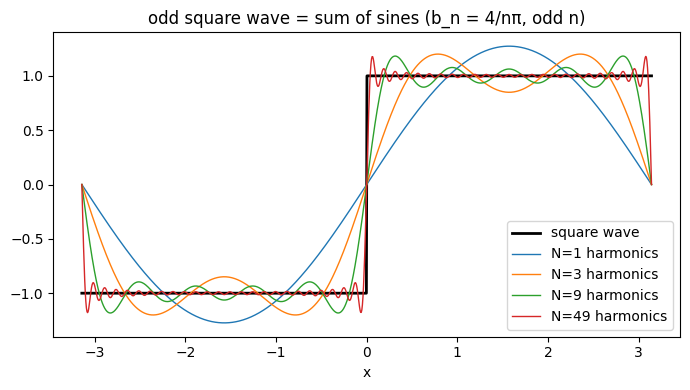

In [2]:
a, b = fs.fourier_coefficients(np.sign, L, N=20)
print(f"max|a_n| = {np.max(np.abs(a)):.1e} (no cosines, odd fn);  b_1 = {b[1]:.4f} = 4/pi = {4/np.pi:.4f}")
x = np.linspace(-L, L, 1000)
plt.figure(figsize=(7, 4))
plt.plot(x, np.sign(x), "k", lw=2, label="square wave")
for N in (1, 3, 9, 49):
    aN, bN = fs.fourier_coefficients(np.sign, L, N=N)
    plt.plot(x, fs.reconstruct(x, aN, bN, L), lw=1, label=f"N={N} harmonics")
plt.legend(loc="lower right"); plt.title("odd square wave = sum of sines (b_n = 4/n\u03c0, odd n)")
plt.xlabel("x"); plt.tight_layout(); plt.show()

## 2. The spectrum -- which harmonics carry the energy

Plotting $b_n$ vs $n$ shows the square wave is built from odd harmonics with
amplitude falling as $1/n$. The even harmonics are exactly zero (odd-function
symmetry).

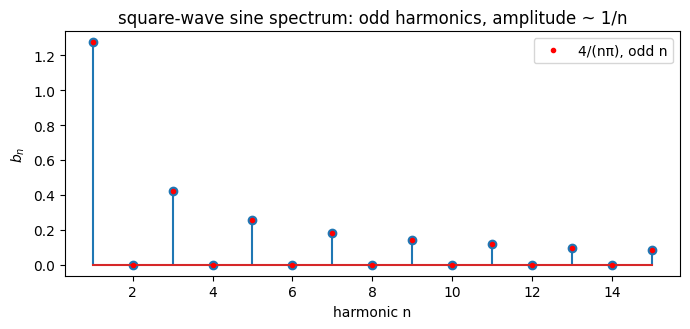

In [3]:
a, b = fs.fourier_coefficients(np.sign, L, N=15)
ns = np.arange(1, len(b))
plt.figure(figsize=(7, 3.4))
plt.stem(ns, b[1:])
plt.plot(ns, [4/(n*np.pi) if n % 2 else 0 for n in ns], "r.", label="4/(n\u03c0), odd n")
plt.xlabel("harmonic n"); plt.ylabel("$b_n$"); plt.legend()
plt.title("square-wave sine spectrum: odd harmonics, amplitude ~ 1/n")
plt.tight_layout(); plt.show()

## 3. Even triangle $|x|$ -> a pure COSINE series

Flip the symmetry: $|x|$ is **even**, so all sine coefficients vanish and it is a
sum of cosines, $a_n=-\dfrac{4}{\pi n^2}$ for odd $n$. The $1/n^2$ falloff (vs the
square wave's $1/n$) is why the triangle's series converges faster -- no jump.

max|b_n| = 2.1e-16 (no sines, even fn);  mean a_0/2 = 1.5708 = pi/2


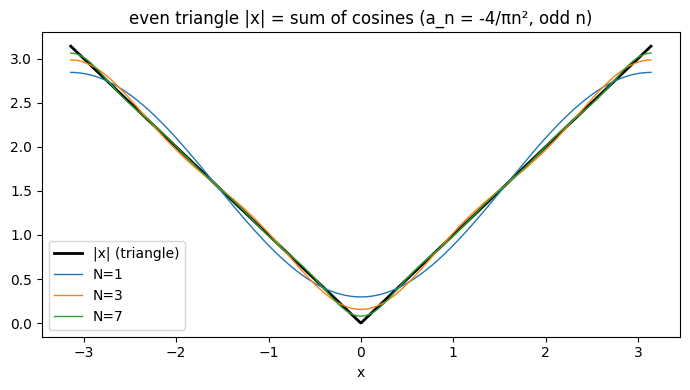

In [4]:
a, b = fs.fourier_coefficients(np.abs, L, N=20)
print(f"max|b_n| = {np.max(np.abs(b)):.1e} (no sines, even fn);  mean a_0/2 = {a[0]/2:.4f} = pi/2")
x = np.linspace(-L, L, 1000)
plt.figure(figsize=(7, 4))
plt.plot(x, np.abs(x), "k", lw=2, label="|x| (triangle)")
for N in (1, 3, 7):
    aN, bN = fs.fourier_coefficients(np.abs, L, N=N)
    plt.plot(x, fs.reconstruct(x, aN, bN, L), lw=1, label=f"N={N}")
plt.legend(); plt.title("even triangle |x| = sum of cosines (a_n = -4/\u03c0n\u00b2, odd n)")
plt.xlabel("x"); plt.tight_layout(); plt.show()

## 4. The Gibbs phenomenon -- the overshoot that never leaves

Near a jump the partial sum **overshoots** by about 8.95% of the jump height, no
matter how many terms you add. The lobe only gets *narrower*, never *shorter*. For
$\mathrm{sign}(x)$ (jump $=2$) the peak sits near $1+0.0895\times2\approx1.18$.
This is why hard edges are hard to represent with finite bandwidth.

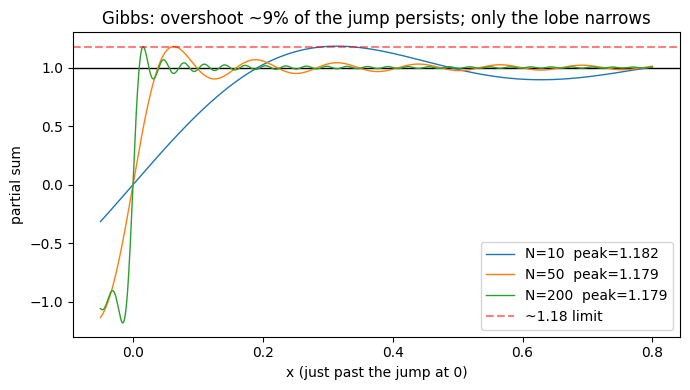

overshoot persists: [1.182, 1.179, 1.179]


In [5]:
x = np.linspace(-0.05, 0.8, 2000)
plt.figure(figsize=(7, 4))
plt.axhline(1.0, color="k", lw=1)
for N in (10, 50, 200):
    a, b = fs.fourier_coefficients(np.sign, L, N=N)
    plt.plot(x, fs.reconstruct(x, a, b, L), lw=1, label=f"N={N}  peak={fs.gibbs_overshoot(a,b,L):.3f}")
plt.axhline(1.0895*1 + 0.0895, color="r", ls="--", alpha=0.5, label="~1.18 limit")
plt.legend(); plt.title("Gibbs: overshoot ~9% of the jump persists; only the lobe narrows")
plt.xlabel("x (just past the jump at 0)"); plt.ylabel("partial sum"); plt.tight_layout(); plt.show()
print("overshoot persists:", [round(fs.gibbs_overshoot(*fs.fourier_coefficients(np.sign,L,N=N), L=L),3)
                              for N in (10,50,200)])

## 5. Convergence rate: smoothness sets the falloff

The smoother the signal, the faster its coefficients decay and the better a few
terms reconstruct it: square wave (a jump) $\sim 1/n$, triangle (a kink) $\sim
1/n^2$, a smooth sine = one term. Plotting the reconstruction error vs the number
of terms makes this concrete.

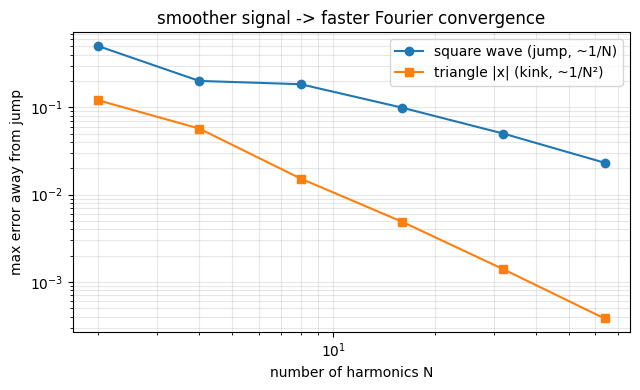

In [6]:
xs = np.linspace(-L+0.4, L-0.4, 300); xs = xs[np.abs(xs) > 0.4]   # away from jumps
Ns = [2, 4, 8, 16, 32, 64]
err_sq = [np.max(np.abs(fs.reconstruct(xs, *fs.fourier_coefficients(np.sign, L, N=N), L=L) - np.sign(xs))) for N in Ns]
err_tr = [np.max(np.abs(fs.reconstruct(xs, *fs.fourier_coefficients(np.abs, L, N=N), L=L) - np.abs(xs))) for N in Ns]
plt.figure(figsize=(6.5, 4))
plt.loglog(Ns, err_sq, "o-", label="square wave (jump, ~1/N)")
plt.loglog(Ns, err_tr, "s-", label="triangle |x| (kink, ~1/N\u00b2)")
plt.xlabel("number of harmonics N"); plt.ylabel("max error away from jump")
plt.legend(); plt.title("smoother signal -> faster Fourier convergence"); plt.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

## What you proved

1. A periodic signal = a sum of harmonics; each coefficient is a **projection**
   (an integral) of $f$ onto that harmonic.
2. **Even -> cosines, odd -> sines** -- the symmetry from `dgs.even_odd` zeroes half
   the coefficients before you compute anything.
3. The coefficient **decay rate** is set by smoothness: jump $\sim1/n$, kink
   $\sim1/n^2$, smooth = finite.
4. **Gibbs**: a finite series overshoots a jump by ~9% of its height forever.

This sine/cosine basis is the continuous parent of the **DFT/FFT** -- the exact
basis the dispersion operator $H(f)=e^{i\pi Df^2}$ and the GS phase-retrieval loop
operate in. Fourier series is where "work in the frequency domain" begins. Civilian
education.